# Qwen Evaluation Results Visualization

This notebook visualizes the results from the Qwen evaluation experiment, showing NDCG@10 scores and comparison counts for different ranking algorithms.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (16, 10)

In [26]:
# Load summary data
summary_path = Path('../reports/qwen_evaluation_summary.csv')
df = pd.read_csv(summary_path)

print(f"Loaded {len(df)} rows")
print(f"\nModels: {df['Model'].unique()}")
print(f"Datasets: {df['Dataset'].unique()}")
print(f"Rankers: {df['Ranker'].unique()}")
df.head()

Loaded 56 rows

Models: ['qwen3-0.6b' 'qwen3-4b-instruct']
Datasets: ['dl-2019' 'dl-2020']
Rankers: ['bubble sort (classic)' 'mohajer (ir)' 'mohajer + bubble' 'pac + bubble'
 'pac top-k (optimized)' 'prp sort (classic)' 'quick sort (classic)']


,Model,Dataset,Ranker,Oracle,Avg_NDCG@10,Avg_Comparisons,Avg_PromptTokens
0,qwen3-0.6b,dl-2019,bubble sort (classic),bidirectional,0.505831,523.720930,102.563764
1,qwen3-0.6b,dl-2019,bubble sort (classic),sampling,0.505831,261.860465,102.563764
2,qwen3-0.6b,dl-2019,mohajer (ir),bidirectional,0.220356,740.372093,101.353422
3,qwen3-0.6b,dl-2019,mohajer (ir),sampling,0.220356,520.534884,102.305899
4,qwen3-0.6b,dl-2019,mohajer + bubble,bidirectional,0.220356,750.372093,103.312325


In [27]:
def plot_model_dataset(model_name, dataset_name, df):
    """Create bar plot for a specific model and dataset."""
    
    # Filter data
    data = df[(df['Model'] == model_name) & (df['Dataset'] == dataset_name)]
    
    if data.empty:
        print(f"No data for {model_name} on {dataset_name}")
        return
    
    # Get unique rankers (sorted by bidirectional NDCG descending)
    rankers = data[data['Oracle'] == 'bidirectional'].sort_values('Avg_NDCG@10', ascending=False)['Ranker'].tolist()
    
    # Prepare data for plotting
    x = np.arange(len(rankers))
    width = 0.35
    
    bidirectional_data = []
    sampling_data = []
    bidirectional_comps = []
    sampling_comps = []
    
    for ranker in rankers:
        bi_row = data[(data['Ranker'] == ranker) & (data['Oracle'] == 'bidirectional')]
        samp_row = data[(data['Ranker'] == ranker) & (data['Oracle'] == 'sampling')]
        
        bidirectional_data.append(bi_row['Avg_NDCG@10'].values[0] if not bi_row.empty else 0)
        sampling_data.append(samp_row['Avg_NDCG@10'].values[0] if not samp_row.empty else 0)
        bidirectional_comps.append(bi_row['Avg_Comparisons'].values[0] if not bi_row.empty else 0)
        sampling_comps.append(samp_row['Avg_Comparisons'].values[0] if not samp_row.empty else 0)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Create bars
    bars1 = ax.bar(x - width/2, bidirectional_data, width, label='Bidirectional', alpha=0.8, color='#2E86AB')
    bars2 = ax.bar(x + width/2, sampling_data, width, label='Sampling', alpha=0.8, color='#A23B72')
    
    # Add comparison counts on top of bars
    # We'll annotate both bars, but make the count for the lower of the two bold.
    for i in range(len(rankers)):
        bi_bar = bars1[i]
        samp_bar = bars2[i]

        bi_height = bi_bar.get_height()
        samp_height = samp_bar.get_height()

        bi_comps = int(bidirectional_comps[i]) if bidirectional_comps[i] else 0
        samp_comps = int(sampling_comps[i]) if sampling_comps[i] else 0

        # Determine which bar is lower (by height)
        lower_is_bi = bi_height < samp_height

        # Small vertical offset so text sits slightly above the bar
        y_offset = max(max(bi_height, samp_height) * 0.01, 0.001)

        # Bidirectional bar annotation
        if bi_comps > 0:
            weight = 'bold' if lower_is_bi else 'normal'
            ax.text(bi_bar.get_x() + bi_bar.get_width()/2., bi_height + y_offset,
                    f'n={bi_comps}', ha='center', va='bottom', fontsize=11, fontweight=weight)

        # Sampling bar annotation
        if samp_comps > 0:
            weight = 'bold' if (not lower_is_bi) else 'normal'
            ax.text(samp_bar.get_x() + samp_bar.get_width()/2., samp_height + y_offset,
                    f'n={samp_comps}', ha='center', va='bottom', fontsize=11, fontweight=weight)
    
    # Customize plot
    ax.set_ylabel('NDCG@10', fontsize=14, fontweight='bold')
    ax.set_xlabel('Ranking Algorithm', fontsize=14, fontweight='bold')
    ax.set_title(f'{model_name} on {dataset_name.upper()}\nNDCG@10 Scores with Average Comparisons', 
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(rankers, rotation=45, ha='right', fontsize=11)
    ax.legend(fontsize=12, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(max(bidirectional_data), max(sampling_data)) * 1.15)
    
    # Add note about comparison numbers
    ax.text(0.02, 0.98, 'Numbers on bars = Avg. Comparisons', 
           transform=ax.transAxes, fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    # Save figure
    output_dir = Path('../reports/qwen_evaluation_plots')
    output_dir.mkdir(exist_ok=True)
    output_path = output_dir / f'{model_name}_{dataset_name}.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Saved plot to {output_path}")
    
    plt.show()
    
    return fig, ax

## Qwen3-0.6B Results

Saved plot to ../reports/qwen_evaluation_plots/qwen3-0.6b_dl-2019.png


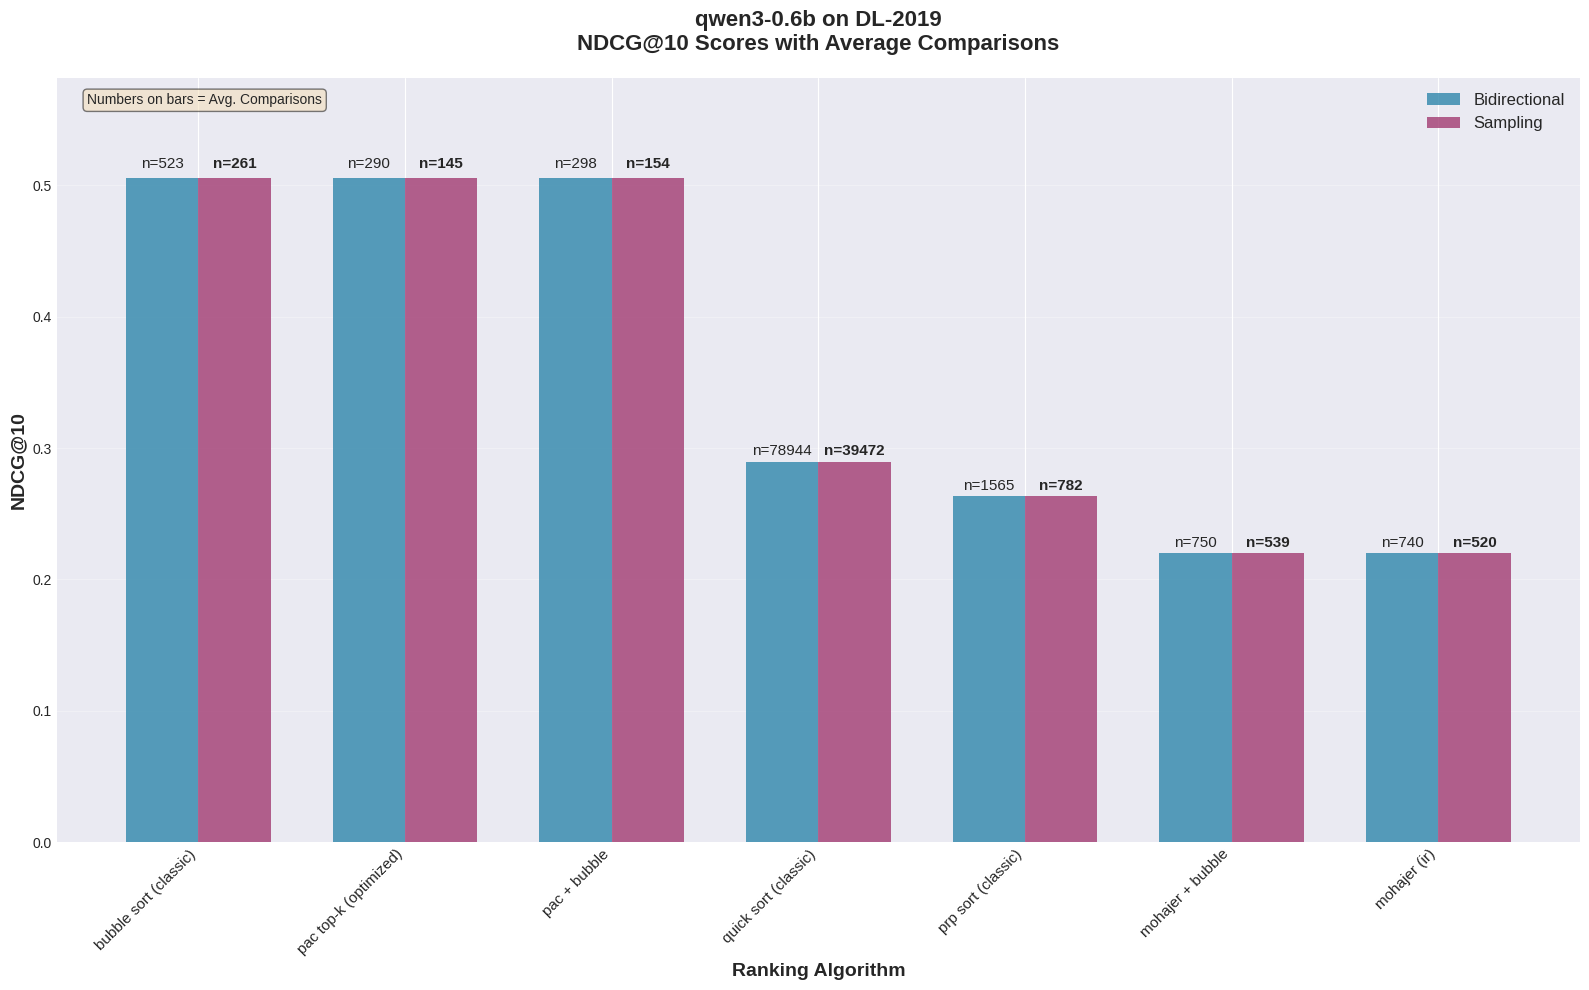

(<Figure size 1600x1000 with 1 Axes>,
 <Axes: title={'center': 'qwen3-0.6b on DL-2019\nNDCG@10 Scores with Average Comparisons'}, xlabel='Ranking Algorithm', ylabel='NDCG@10'>)

In [28]:
# Plot qwen3-0.6b on dl-2019
plot_model_dataset('qwen3-0.6b', 'dl-2019', df)

Saved plot to ../reports/qwen_evaluation_plots/qwen3-0.6b_dl-2020.png


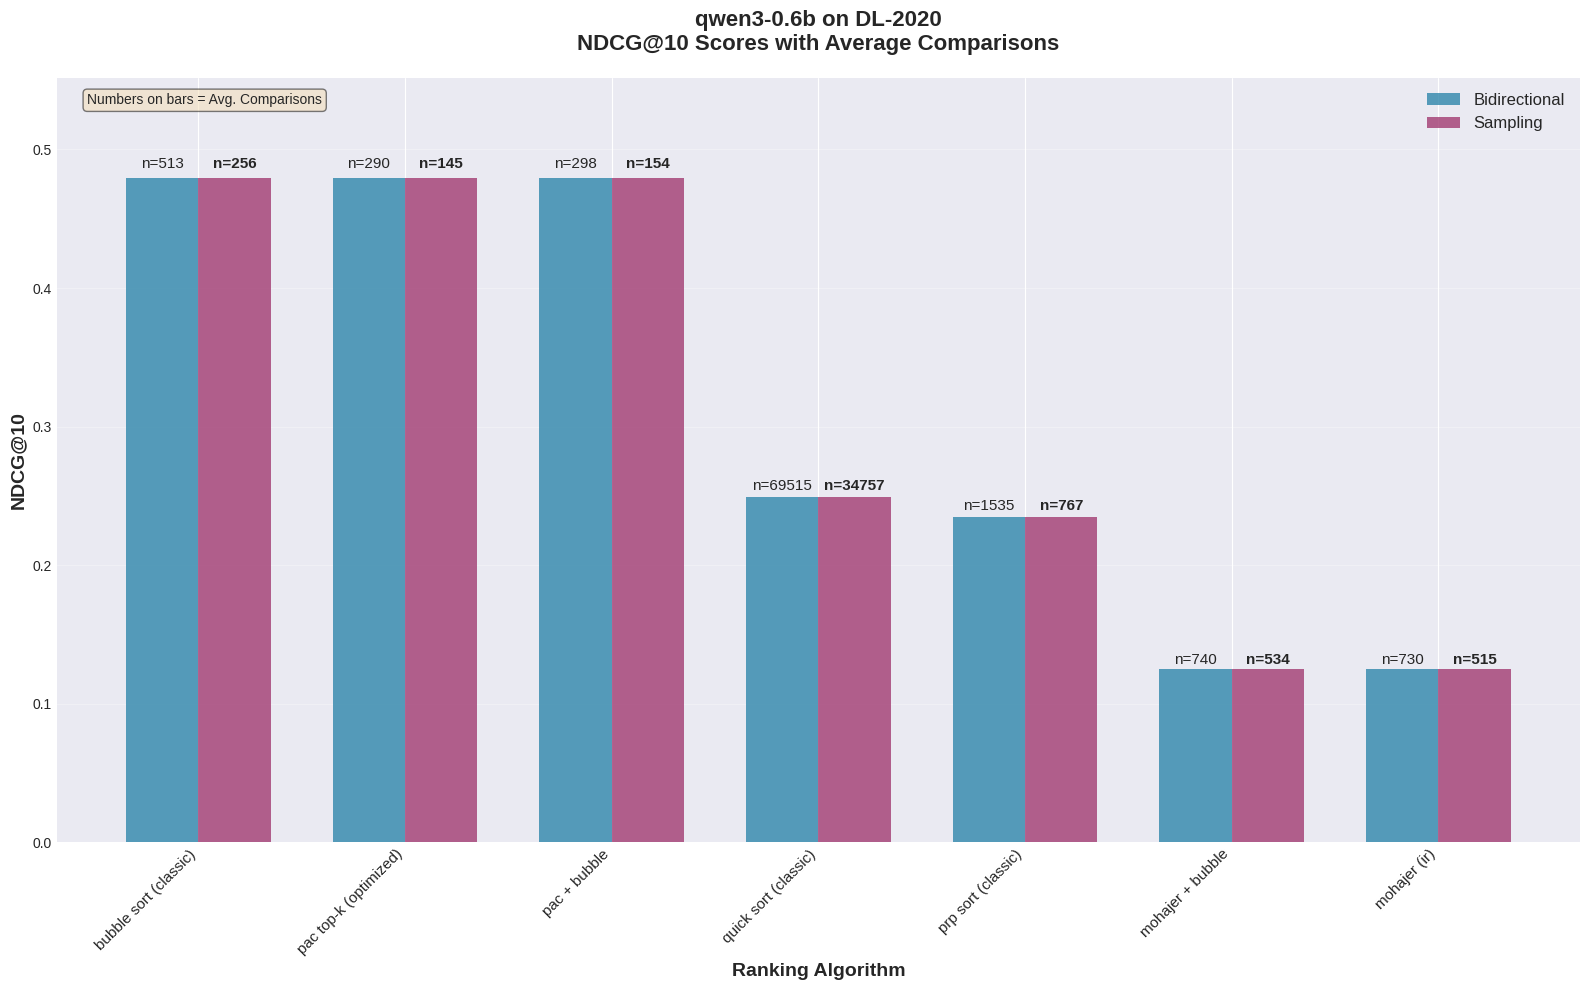

(<Figure size 1600x1000 with 1 Axes>,
 <Axes: title={'center': 'qwen3-0.6b on DL-2020\nNDCG@10 Scores with Average Comparisons'}, xlabel='Ranking Algorithm', ylabel='NDCG@10'>)

In [29]:
# Plot qwen3-0.6b on dl-2020
plot_model_dataset('qwen3-0.6b', 'dl-2020', df)

## Qwen3-4B-Instruct Results

Saved plot to ../reports/qwen_evaluation_plots/qwen3-4b-instruct_dl-2019.png


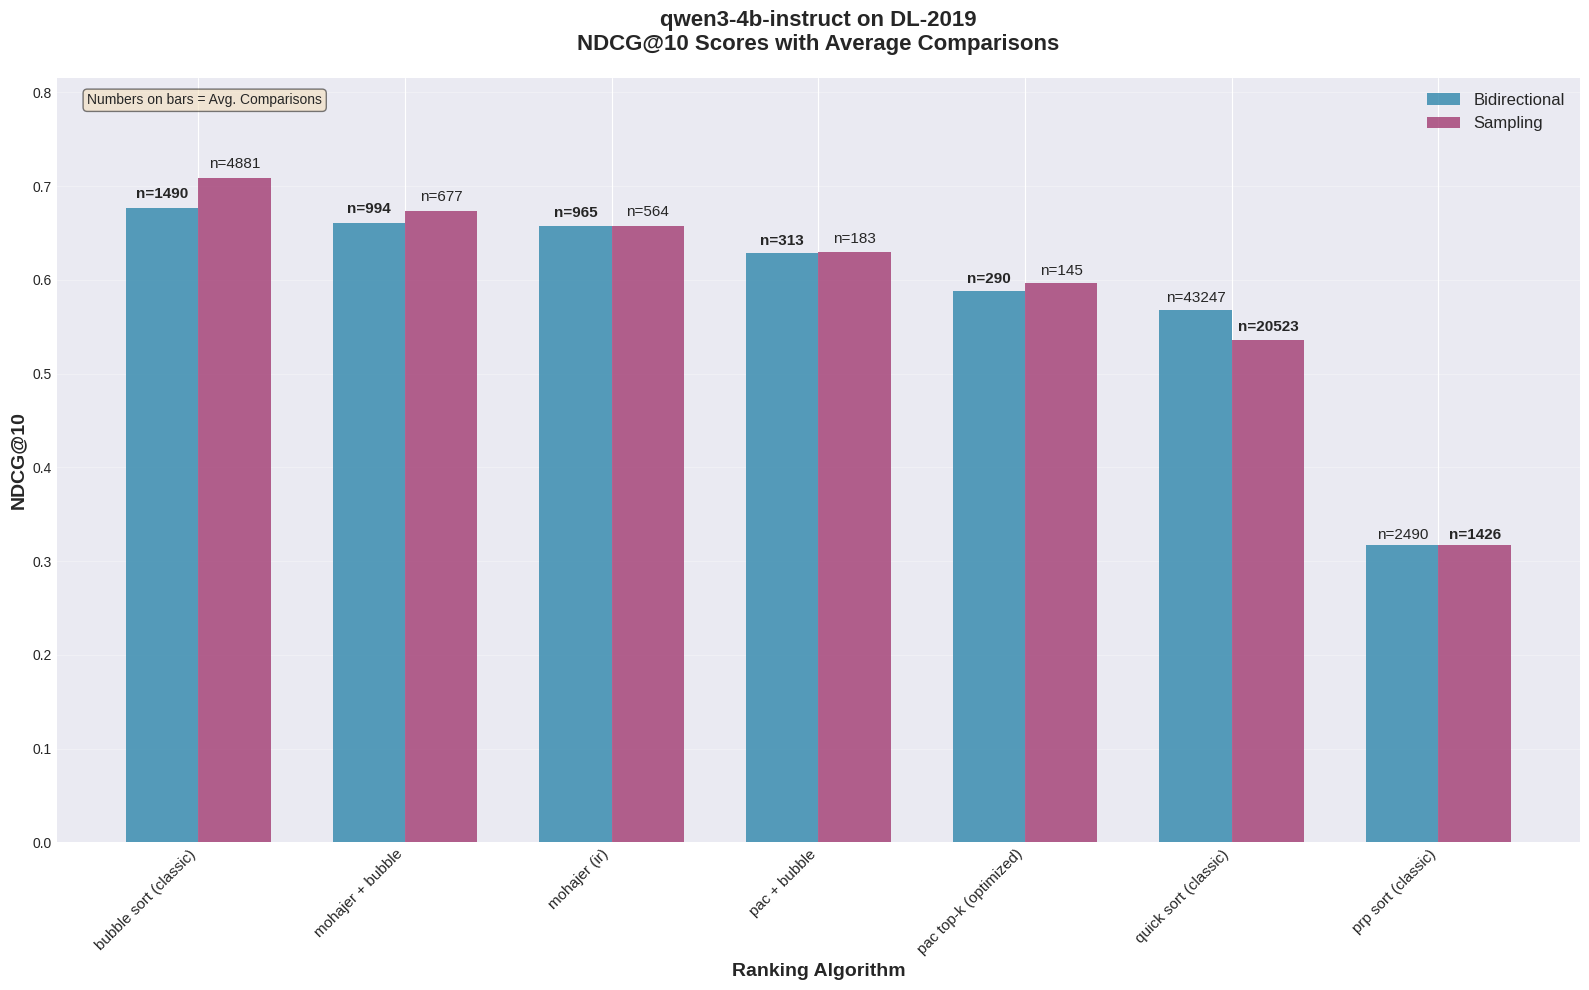

(<Figure size 1600x1000 with 1 Axes>,
 <Axes: title={'center': 'qwen3-4b-instruct on DL-2019\nNDCG@10 Scores with Average Comparisons'}, xlabel='Ranking Algorithm', ylabel='NDCG@10'>)

In [30]:
# Plot qwen3-4b-instruct on dl-2019
plot_model_dataset('qwen3-4b-instruct', 'dl-2019', df)

Saved plot to ../reports/qwen_evaluation_plots/qwen3-4b-instruct_dl-2020.png


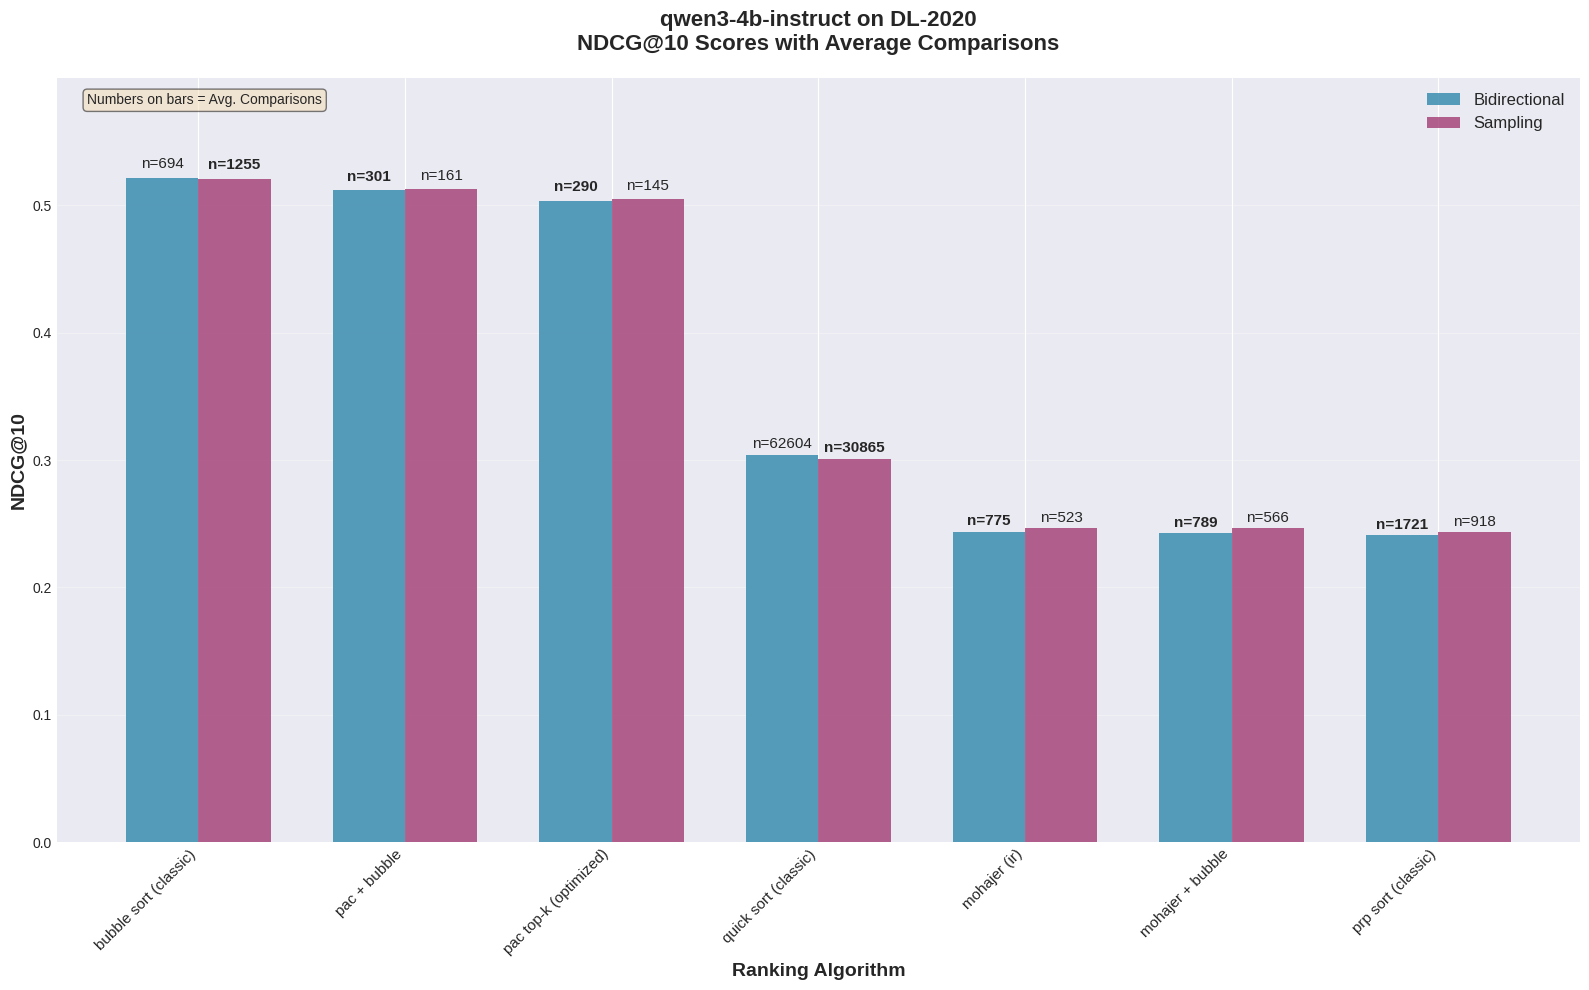

(<Figure size 1600x1000 with 1 Axes>,
 <Axes: title={'center': 'qwen3-4b-instruct on DL-2020\nNDCG@10 Scores with Average Comparisons'}, xlabel='Ranking Algorithm', ylabel='NDCG@10'>)

In [31]:
# Plot qwen3-4b-instruct on dl-2020
plot_model_dataset('qwen3-4b-instruct', 'dl-2020', df)

## Summary Statistics Table

In [32]:
# Create summary table showing top performers
for model in df['Model'].unique():
    for dataset in df['Dataset'].unique():
        print(f"\n{'='*80}")
        print(f"{model} on {dataset}")
        print(f"{'='*80}")
        
        model_data = df[(df['Model'] == model) & (df['Dataset'] == dataset)].copy()
        
        if model_data.empty:
            continue
        
        # Sort by NDCG@10 descending
        model_data = model_data.sort_values('Avg_NDCG@10', ascending=False)
        
        # Format for display
        display_cols = ['Ranker', 'Oracle', 'Avg_NDCG@10', 'Avg_Comparisons', 'Avg_PromptTokens']
        display_data = model_data[display_cols].copy()
        display_data['Avg_NDCG@10'] = display_data['Avg_NDCG@10'].apply(lambda x: f"{x:.4f}")
        display_data['Avg_Comparisons'] = display_data['Avg_Comparisons'].apply(lambda x: f"{int(x)}")
        display_data['Avg_PromptTokens'] = display_data['Avg_PromptTokens'].apply(lambda x: f"{x:.2f}")
        
        print(display_data.to_string(index=False))


qwen3-0.6b on dl-2019
               Ranker        Oracle Avg_NDCG@10 Avg_Comparisons Avg_PromptTokens
bubble sort (classic) bidirectional      0.5058             523           102.56
bubble sort (classic)      sampling      0.5058             261           102.56
pac top-k (optimized)      sampling      0.5058             145           247.17
pac top-k (optimized) bidirectional      0.5058             290           247.17
         pac + bubble      sampling      0.5058             154           247.16
         pac + bubble bidirectional      0.5058             298           247.14
 quick sort (classic)      sampling      0.2898           39472            46.37
 quick sort (classic) bidirectional      0.2898           78944            46.37
   prp sort (classic)      sampling      0.2633             782           101.81
   prp sort (classic) bidirectional      0.2633            1565           101.81
     mohajer + bubble      sampling      0.2204             539           104.73
     